### Library for the project

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models


### Load the Dataset

In [46]:
print("Loading the data...please wait...")
#Train data
x_train = np.load("data/k49-train-imgs.npz")['arr_0']
y_train = np.load("data/k49-train-labels.npz")['arr_0']

#Test data
x_test = np.load("data/k49-test-imgs.npz")['arr_0']
y_test = np.load("data/k49-test-labels.npz")['arr_0']

print("Data loaded.")
#Check the shape of train data
print(f"X Train shape: {x_train.shape}")
print(f"Y Train shape: {y_train.shape}")

Loading the data...please wait...
Data loaded.
X Train shape: (232365, 28, 28)
Y Train shape: (232365,)


Character label: と (index: 19)


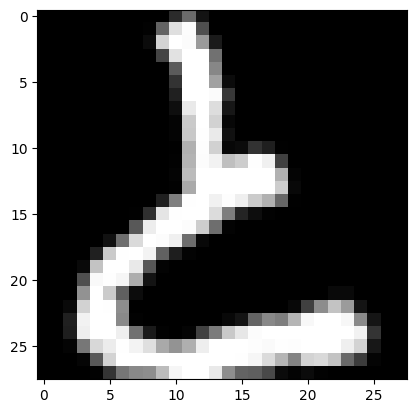

In [47]:
index = 1
k49_classmap = [
    'あ', 'い', 'う', 'え', 'お', 'か', 'き', 'く', 'け', 'こ', 
    'さ', 'し', 'す', 'せ', 'そ', 'た', 'ち', 'つ', 'て', 'と', 
    'な', 'に', 'ぬ', 'ね', 'の', 'は', 'ひ', 'ふ', 'へ', 'ほ', 
    'ま', 'み', 'む', 'め', 'も', 'や', 'ゆ', 'よ', 
    'ら', 'り', 'る', 'れ', 'ろ', 'わ', 'ゐ', 'ゑ', 'を', 'ん', 'ゝ'
]

selected_iamge = x_train[index]
character_name = k49_classmap[y_train[index]]
print(f"Character label: {character_name} (index: {y_train[index]})")
plt.imshow(selected_iamge, cmap='gray')
plt.show()

In [48]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print(f"X Train shape after expanding dims: {x_train.shape}")

X Train shape after expanding dims: (232365, 28, 28, 1)


### Create the CNN Layer

In [49]:
#Make the sequence layers system
model = models.Sequential()

#Scanning layers
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

#Scanning deep layers
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

#Flat all the layers and dense it with 128 neurons
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dropout(0.5))

#Output layer with 49 neurons for 49 classes
model.add(layers.Dense(49,activation='softmax'))

c:\Users\63ana\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Model compile stage integrated with rules

In [50]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 49)             │         6,321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,065 (898.69 KB)

 Trainable params: 230,065 (898.69 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [51]:
print("Start training the model...")

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15
)

print("Training completed.")

Start training the model...
Epoch 1/10
3087/3087 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7233 - loss: 1.0433 - val_accuracy: 0.9027 - val_loss: 0.3588
Epoch 2/10
3087/3087 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8540 - loss: 0.5286 - val_accuracy: 0.9288 - val_loss: 0.2606
Epoch 3/10
3087/3087 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8823 - loss: 0.4199 - val_accuracy: 0.9390 - val_loss: 0.2217
Epoch 4/10
3087/3087 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8977 - loss: 0.3643 - val_accuracy: 0.9467 - val_loss: 0.2010
Epoch 5/10
3087/3087 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9087 - loss: 0.3223 - val_accuracy: 0.9476 - val_loss: 0.1920
Epoch 6/10
3087/3087 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9148 - loss: 0.2977 - val_accuracy: 0.9514 - val_loss: 0.1789
Epoch 7/10
3087/3087 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9198 - loss: 0.2770 - val_accuracy: 0.9546 - val_loss: 0.1730
Epoch 8/10
3087/3087 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step 

### Loss and Accuracy Visualization

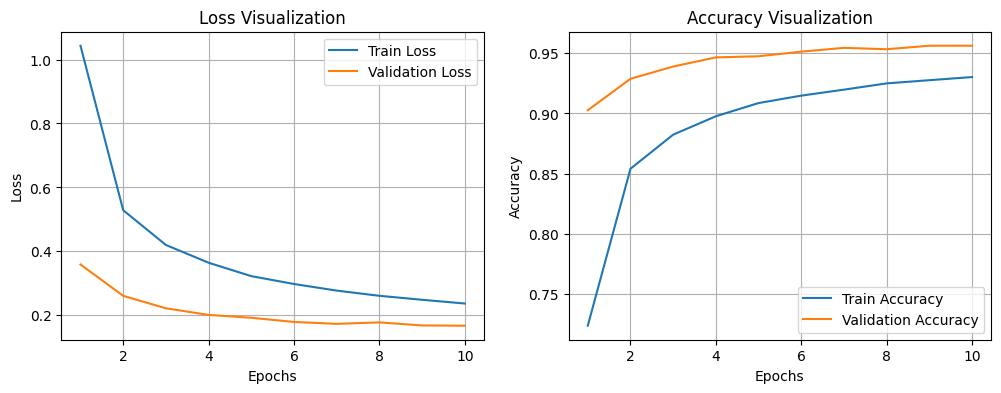

In [52]:
import pandas as pd

data_acc = pd.DataFrame(history.history)

data_acc["epoch"] = range(1, len(data_acc) + 1)

fig , (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))

sns.lineplot(data=data_acc, x="epoch", y="loss", label="Train Loss",ax=ax1, markers='o')
sns.lineplot(data=data_acc, x="epoch", y="val_loss", label="Validation Loss", ax=ax1, markers='o')
ax1.set_title("Loss Visualization")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.grid(True)

sns.lineplot(data=data_acc, x="epoch", y="accuracy", label="Train Accuracy",ax=ax2, markers='o')
sns.lineplot(data=data_acc, x="epoch", y="val_accuracy", label="Validation Accuracy", ax=ax2, markers='o')
ax2.set_title("Accuracy Visualization")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.show()

### Test the model with balanced accuracy

In [53]:
raw_x_test = model.predict(x_test)
p_test = np.argmax(raw_x_test,axis=1)

accs = []

for cls in range(49):
    mask= (y_test) == cls
    cls_acc = (p_test == cls)[mask].mean()
    
    accs.append(cls_acc)
    
balanced_acc = np.mean(accs)
print(f"Balanced Accuracy on Test Data: {balanced_acc*100:.2f}%")

1205/1205 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Balanced Accuracy on Test Data: 90.77%


### Save the model

In [54]:
saved_name = "model_kmnist49.h5" 
model.save(saved_name)

print(f"Model saved as {saved_name}")

Model saved as model_kmnist49.h5
